# Support Vector Machine Models

In [44]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from statsmodels.nonparametric.smoothers_lowess import lowess

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV)

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier, HistGradientBoostingClassifier,
    BaggingRegressor, BaggingClassifier, AdaBoostRegressor)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.inspection import DecisionBoundaryDisplay

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, precision_score, recall_score, 
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, 
    roc_curve, auc, roc_auc_score,RocCurveDisplay, silhouette_score)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')
from patsy import (dmatrix, bs)

# 0. Common Setup

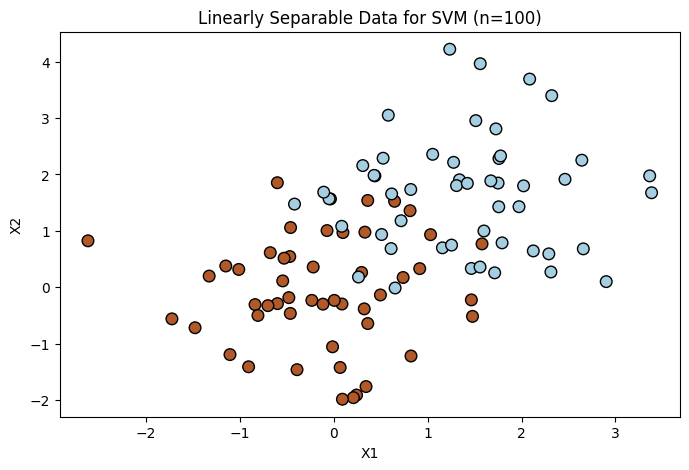

In [135]:
# 1. Generate 100 observations (50 for each class)
np.random.seed(42)
c = 100
X = np.random.randn(c, 2)

# 2. Update y to have 100 elements (50 of '1' and 50 of '-1')
y = np.repeat([1, -1], c/2) 

# 3. Shift the second class to create separation
X[y == -1] = X[y == -1] + 1.5  # Increased shift to 1.5 for clearer visual separation

# 4. Plotting
plt.figure(figsize=(8, 5))
plt.scatter(X[:,0], X[:,1], s=70, c=y, cmap=plt.cm.Paired, edgecolors='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Linearly Separable Data for SVM (n=100)')
plt.show()

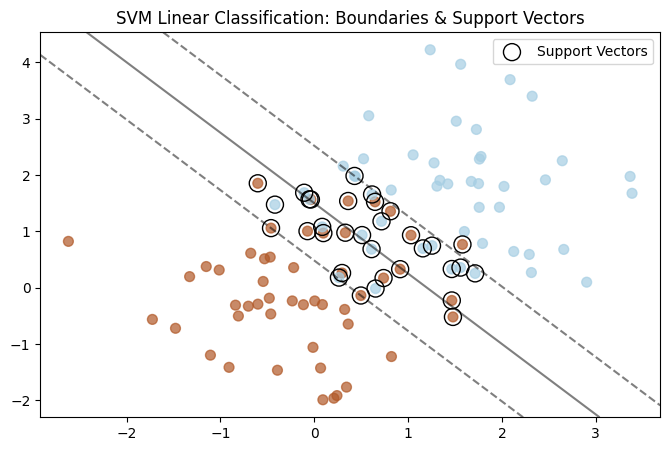

In [134]:
# 1. Fit the Linear SVM Model
# C=1.0 is the "Cost" parameter; higher C means less tolerance for misclassification
model = SVC(kernel='linear', C=1.0)
model.fit(X, y)

# 2. Setup the plot
plt.figure(figsize=(8, 5))
plt.scatter(X[:,0], X[:,1], s=50, c=y, cmap=plt.cm.Paired, alpha=0.7)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# 3. Create a grid to evaluate the model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# 4. Plot Decision Boundary and Margins
# Level 0 is the boundary; Levels -1 and 1 are the margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# 5. Highlight Support Vectors
# These are the specific points that define the position of the line
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=150,
           linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')

plt.title("SVM Linear Classification: Boundaries & Support Vectors")
plt.legend()
plt.show()

In [140]:
# Helper function to plot SVM boundaries
def plot_svm(clf, X, y, ax=None, title="SVM Decision Boundary"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    # 1. Handle both GridSearchCV and standard SVC objects
    # If it's a grid search, we extract the best estimator
    model = clf.best_estimator_ if hasattr(clf, 'best_estimator_') else clf
    
    # 2. Plot the points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap=plt.cm.Paired, alpha=0.7)
    
    # 3. Create higher-resolution grid
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100), 
                         np.linspace(ylim[0], ylim[1], 100))
    
    # 4. Evaluate decision function
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # 5. Plot boundary and margins
    ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    
    # 6. Highlight support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], 
               s=150, facecolors='none', edgecolors='k', linewidth=1.5, label='Support Vectors')
    
    ax.set_title(title)
    ax.legend()

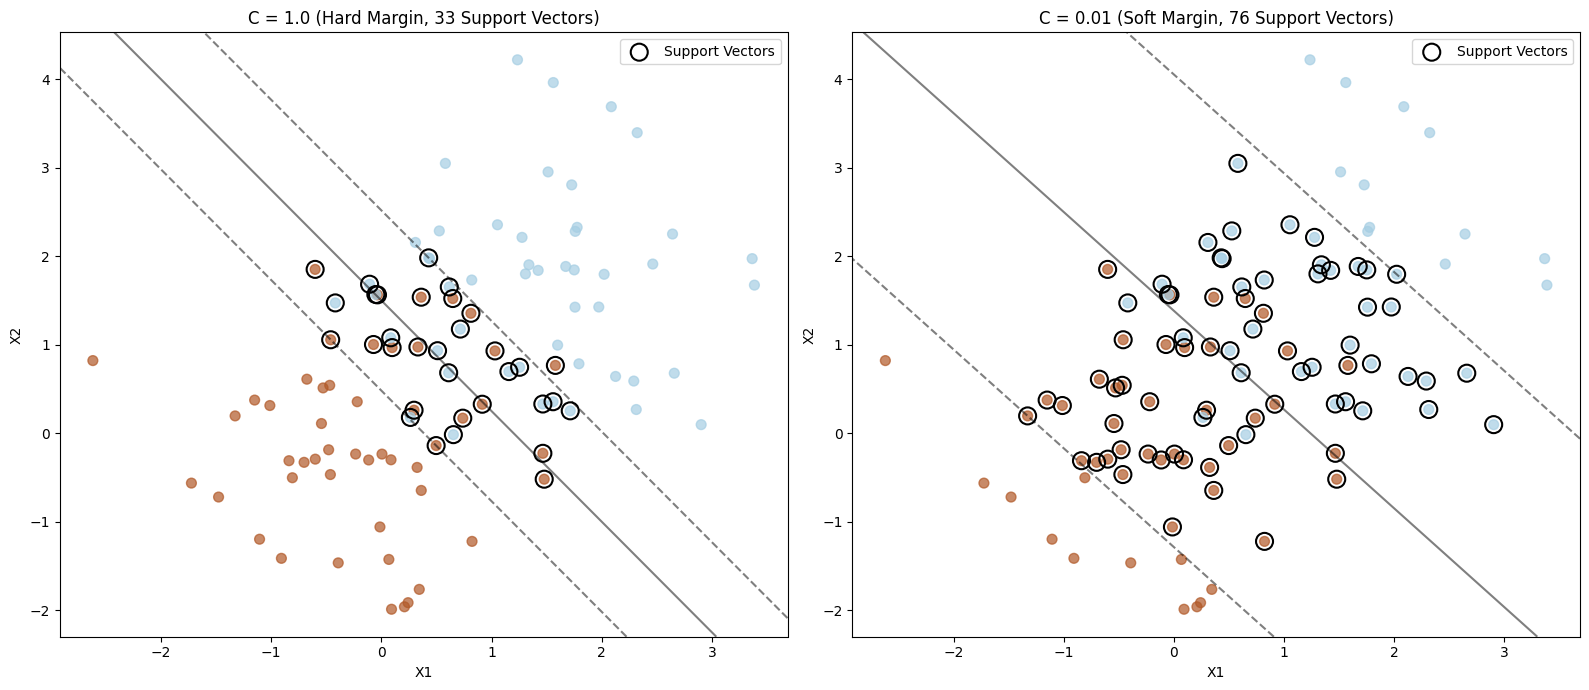

In [105]:
# Create a side-by-side comparison of different C values
plt.figure(figsize=(16, 7))

# --- Subplot 1: Large C (Harder Margin) ---
ax1 = plt.subplot(1, 2, 1)
# Fit the model with a LARGE C value
clf1 = SVC(kernel='linear', C=1.0)
clf1.fit(X, y)

# Use the hybrid function: plot_svm_ultimate(model, X, y, ax, title)
num_sv1 = len(clf1.support_vectors_)
plot_svm(clf1, X, y, ax=ax1, 
                  title=f'C = 1.0 (Hard Margin, {num_sv1} Support Vectors)')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')

# --- Subplot 2: Small C (Softer Margin) ---
ax2 = plt.subplot(1, 2, 2)
# Fit the model with a SMALL C value
clf2 = SVC(kernel='linear', C=0.01)
clf2.fit(X, y)

# Use the hybrid function again
num_sv2 = len(clf2.support_vectors_)
plot_svm(clf2, X, y, ax=ax2, 
                  title=f'C = 0.01 (Soft Margin, {num_sv2} Support Vectors)')
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')

plt.tight_layout()
plt.show()

In [106]:
# Select the optimal C parameter by cross-validation
tuned_parameters = [{'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}]
clf = GridSearchCV(SVC(kernel='linear'), 
                   tuned_parameters, cv=10, scoring='accuracy', 
                   return_train_score=True)
clf.fit(X, y)

GridSearchCV(cv=10, estimator=SVC(kernel='linear'),
             param_grid=[{'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}],
             return_train_score=True, scoring='accuracy')

In [107]:
# Convert results to a dataframe for easy viewing
results_df = pd.DataFrame(clf.cv_results_)

# Focus on the most important columns
display(results_df[['param_C', 'mean_test_score', 'std_test_score', 'rank_test_score']])

# Get the absolute best parameters
print(f"Best C: {clf.best_params_}")
print(f"Best Accuracy: {clf.best_score_}")

,param_C,mean_test_score,std_test_score,rank_test_score
0,0.001,0.86,0.080000,3
1,0.010,0.89,0.083066,1
2,0.100,0.87,0.090000,2
3,1.000,0.86,0.101980,3
4,5.000,0.86,0.101980,3
5,10.000,0.86,0.101980,3
6,100.000,0.85,0.092195,7


Best C: {'C': 0.01}
Best Accuracy: 0.89


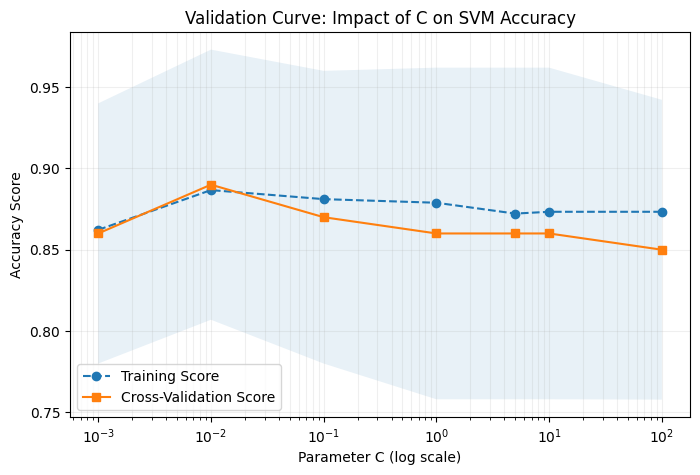

In [133]:
results = pd.DataFrame(clf.cv_results_)
param_c = results['param_C'].astype(float)
train_scores = results['mean_train_score']
test_scores = results['mean_test_score']
std_test = results['std_test_score']

# 2. Plotting
plt.figure(figsize=(8, 5))
plt.semilogx(param_c, train_scores, label='Training Score', marker='o', linestyle='--')
plt.semilogx(param_c, test_scores, label='Cross-Validation Score', marker='s')

# Add a shaded area for the standard deviation (shows consistency)
plt.fill_between(param_c, test_scores - std_test, test_scores + std_test, alpha=0.1)

plt.title("Validation Curve: Impact of C on SVM Accuracy")
plt.xlabel("Parameter C (log scale)")
plt.ylabel("Accuracy Score")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(loc="best")
plt.show()

## Interpreting SVM Hyperparameter Tuning with GridSearchCV

### 1. Breakdown of the Process
When running `GridSearchCV(SVC(kernel='linear'), tuned_parameters, cv=10)`, the following occurs:

*   **10-Fold Cross-Validation (`cv=10`):** The dataset is split into 10 subsets. The model trains on 9 and validates on 1. This repeats 10 times for **each** value of $C$.
*   **Scoring:** The algorithm tracks which $C$ yields the highest **mean accuracy** across those 10 iterations.
*   **Search Space:** Since we provided 7 values for $C$, the grid search fits a total of **70 models** ($7 \text{ values} \times 10 \text{ folds}$).

---

### 2. The Bias-Variance Tradeoff (The $C$ Parameter)
The $C$ parameter acts as a "budget" for misclassifications. By searching from $0.001$ to $100$, we are testing the entire spectrum:

| $C$ Value | Margin Type | Risk | Behavior |
| :--- | :--- | :--- | :--- |
| **Low (0.001)** | **Soft Margin** | **Underfitting** | The margin is so wide it may ignore the actual data structure. |
| **High (100)** | **Hard Margin** | **Overfitting** | The model tries to perfectly classify every point, potentially capturing noise. |

One Small RecommendationSince you are using kernel='linear', the model is relatively simple. If your best $C$ ends up being the very edge of your grid (e.g., 0.001 or 100), it’s a good sign you should extend your search in that direction (e.g., try 0.0001 or 1000) to ensure you haven't missed the true peak performance.

---
### What this plot tells you:

*   **Underfitting Zone (Left side):** When $C$ is very small (e.g., $0.001$), the model is too "relaxed." Both training and validation scores will likely be low because the margin is so wide it ignores the actual data patterns.
*   **Overfitting Zone (Right side):** When $C$ is very high (e.g., $100$), you might see the **Training Score** continue to rise while the **Cross-Validation Score** flattens or drops. This means the model is memorizing noise in the training set.
*   **The "Sweet Spot":** The $C$ value where the Cross-Validation Score is at its peak. This is what your `clf.best_params_` will return.

Based on the Validation Curve:
*   **Optimal Parameter:** The best $C$ value is **0.01** ($10^{-2}$). At this value, the model achieves its highest cross-validation accuracy (~89%) and shows the least amount of overfitting.
*   **Soft vs. Hard Margin:** 
    *   For $C < 0.01$, the model is slightly **underfitting**, as both scores are lower.
    *   For $C > 0.01$, the model begins to **overfit**. The gap between the training score and validation score widens, meaning the model is becoming too complex and "memorizing" the training data rather than learning the general trend.
*   **Conclusion:** We should use `C=0.01` for our final model as it provides the most robust generalization.

---

### Pro-Tip for SVMs
Since the $C$ parameter varies by powers of 10, we use `plt.semilogx`. If your "best $C$" is sitting at the very end of your plot (like $100$), it's a signal to run the grid search again with even higher values (like $1000$ or $10000$) to see if the accuracy keeps improving!

In [136]:
# ==========================================
# 2. THE HOLD-OUT TEST SPLIT
# ==========================================
# We reserve 20% of data as the "Final Exam" (unseen by tuning)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 80 | Test size: 20


In [137]:
# ==========================================
# 3. HYPERPARAMETER TUNING (GridSearchCV)
# ==========================================
# Define the search space for C
param_grid = {'C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}

# Setup Grid Search with 10-fold cross-validation
# This will perform 70 fits total (7 C-values * 10 folds)
grid_search = GridSearchCV(
    SVC(kernel='linear'), 
    param_grid, 
    cv=10, 
    scoring='accuracy', 
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# Print tuning results
print(f"Best C Parameter: {grid_search.best_params_['C']}")
print(f"Best CV Accuracy: {grid_search.best_score_:.2%}")

Best C Parameter: 0.01
Best CV Accuracy: 87.50%



--- Performance on Final Test Set (Locked Data) ---
Test Accuracy: 90.00%

Confusion Matrix:


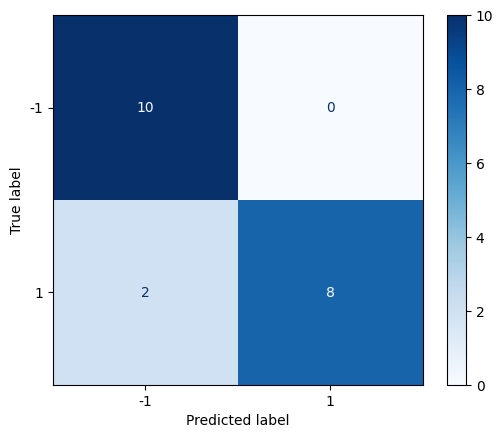


Full Report:


,precision,recall,f1-score,support
-1,0.833333,1.0,0.909091,10.0
1,1.000000,0.8,0.888889,10.0
accuracy,0.900000,0.9,0.900000,0.9
macro avg,0.916667,0.9,0.898990,20.0
weighted avg,0.916667,0.9,0.898990,20.0


In [138]:
# ==========================================
# 4. FINAL EVALUATION
# ==========================================
# Use the best model found by GridSearchCV to predict the test set
y_pred = grid_search.predict(X_test)

print("\n--- Performance on Final Test Set (Locked Data) ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.show()
print("\nFull Report:")
report = classification_report(y_test, y_pred, output_dict=True)
report = pd.DataFrame(report).transpose()
display(report)

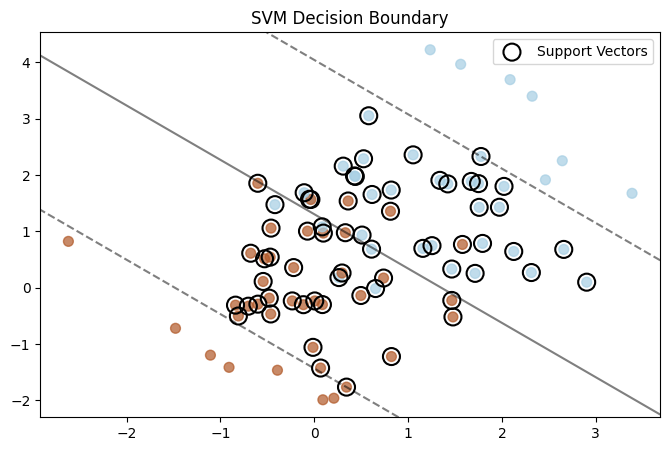

In [141]:
plot_svm(grid_search, X_train, y_train, ax=None, title="SVM Decision Boundary")

## Binary Classification

The code creates a 2D dataset with 200 points. It shifts the first 100 points and the next 50 points in opposite directions to create overlapping clusters, then assigns labels (Class 1 and Class 2).2. Key Components & TransitionsThe RBF Kernel: Unlike a linear SVM, the RBF kernel allows the model to create circular or "blob-like" decision boundaries.The Gamma ($\gamma$) Parameter: Controls the "reach" of a single training point. High gamma leads to tight, wiggly boundaries (overfitting), while low gamma creates smoother curves.The C Parameter: The penalty for misclassification. High $C$ aims for a perfect fit on training data; low $C$ allows for a wider "street" (margin).

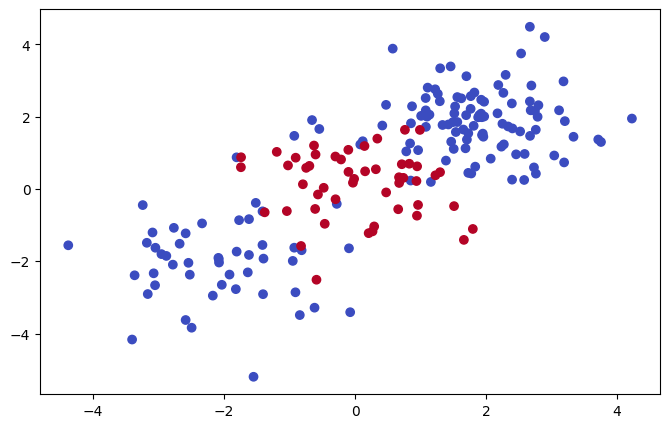

In [142]:
X = rng.standard_normal((200, 2))
X[:100] += 2
X[100:150] -= 2
y = np.array([1]*150+[2]*50)
# Plotting the data makes it clear that the class boundary is indeed nonlinear.
fig , ax = plt.subplots(figsize=(8,5))
ax.scatter(X[:,0], 
           X[:,1],
           c=y,
           cmap= 'coolwarm')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=0)

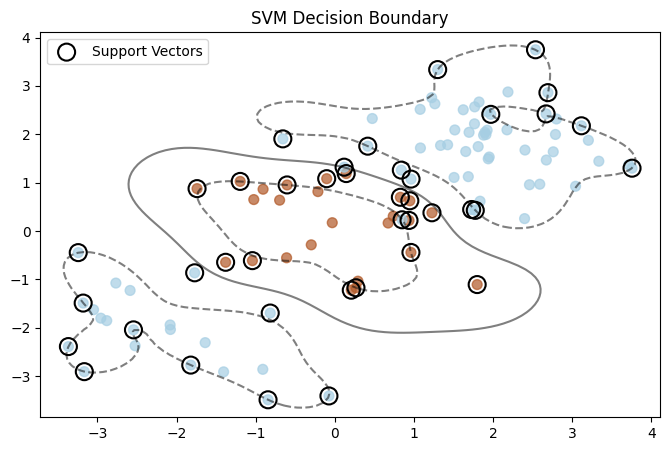

In [143]:
# 3. Fit and Plot (Example: High Penalty C)
svm_rbf = SVC(kernel="rbf", gamma=1, C=1).fit(X_train, y_train)
plot_svm(svm_rbf, X_train, y_train)

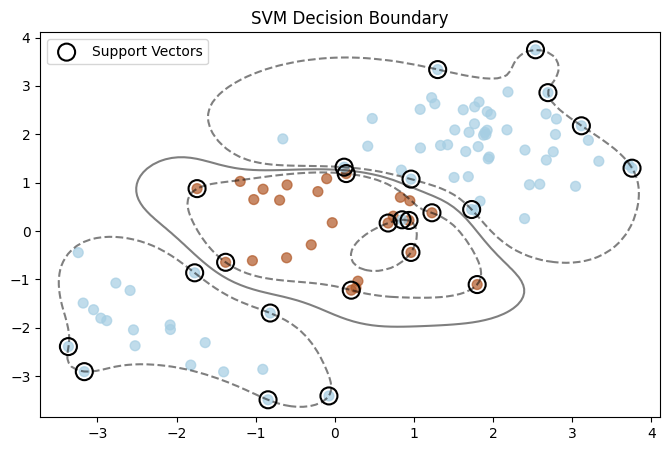

In [144]:
# larger C
svm_rbf = SVC(kernel="rbf", gamma=1, C=100).fit(X_train, y_train)
plot_svm(svm_rbf, X_train, y_train)

Best Params: {'C': 100, 'gamma': 0.5}


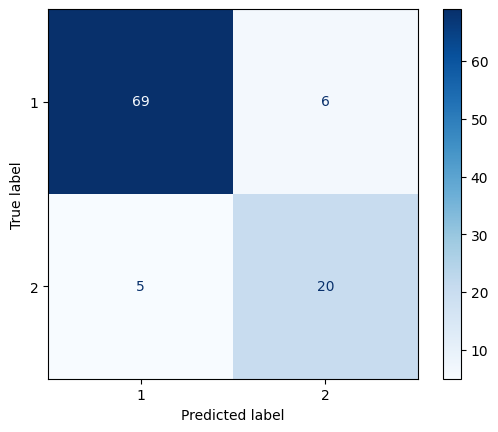

In [145]:
# 4. Hyperparameter Tuning
kfold = KFold(5, random_state=0, shuffle=True)
grid = GridSearchCV(
    SVC(kernel="rbf"),
    {'C': [0.1, 1, 10, 100, 1000], 'gamma': [0.5, 1, 2, 3, 4]},
    cv=kfold,
    scoring='accuracy'
).fit(X_train, y_train)

best_svm = grid.best_estimator_
print(f"Best Params: {grid.best_params_}")

# 5. Confusion Matrix (Replaces confusion_table)
ConfusionMatrixDisplay.from_estimator(best_svm, X_test, y_test,cmap='Blues')
plt.show()

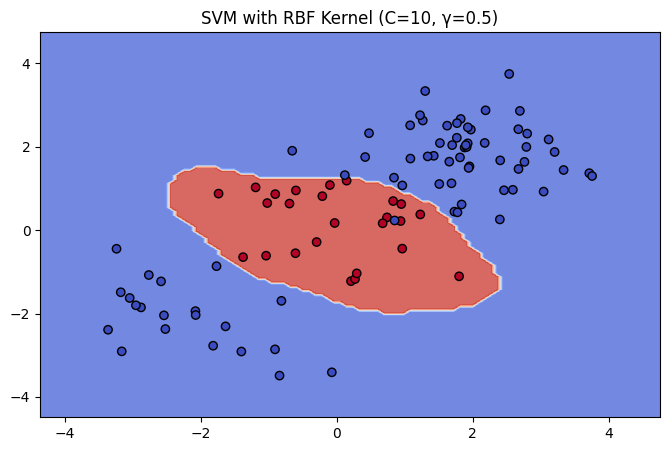

In [146]:
# 2. Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Draw the decision regions (the shaded background)
DecisionBoundaryDisplay.from_estimator(
    svm_rbf,
    X_train,
    response_method="predict", # This tells it to color by class prediction
    cmap=plt.cm.coolwarm,      # Matches your previous color scheme
    alpha=0.8,                 # Transparency of the background
    ax=ax
)

# 3. Overlay the actual data points
ax.scatter(
    X_train[:, 0], 
    X_train[:, 1], 
    c=y_train, 
    cmap=plt.cm.coolwarm, 
    edgecolors="k"
)

ax.set_title("SVM with RBF Kernel (C=10, γ=0.5)")
plt.show()

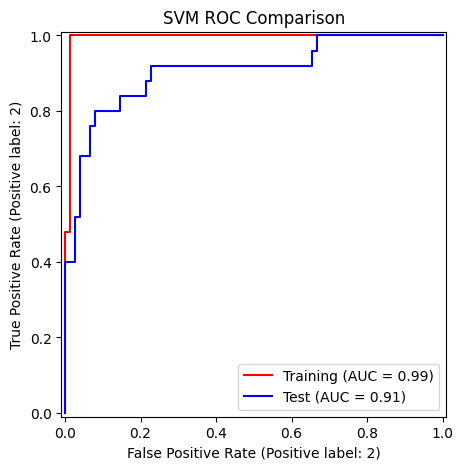

In [147]:
fig, ax = plt.subplots(figsize=(8,5))

# Plot Training ROC
RocCurveDisplay.from_estimator(
    best_svm, X_train, y_train, ax=ax, name='Training', color='r')

# Plot Test ROC on the same axes
RocCurveDisplay.from_estimator(
    best_svm, X_test, y_test, ax=ax, name='Test', color='b')

ax.set_title("SVM ROC Comparison")
plt.show()

## Multiclass Classification
The complexity of the problem increases because you are moving from a binary classification (two classes) to a multiclass classification (three classes).

1. Adding a Third ClassThe code generates 50 new data points and stacks them onto your existing $X$ and $y$ arrays.
    - The Data: 50 new points are drawn from a standard normal distribution.
    - The Label: These points are assigned the label 0. (Your previous labels were 1 and 2).
    - The Shift: $X[y==0,1] += 2$ shifts these new "Class 0" points upward by 2 units on the y-axis.The Result: You now have three distinct (but likely overlapping) clusters of data.

2. Multi-Class Strategy: "One-vs-One" (OvO)
The parameter decision_function_shape='ovo' is the most important change here.
Since standard SVMs are mathematically designed to separate only two classes at a time, Scikit-Learn has to use a strategy to handle three classes. 
One-vs-One works as follows:
    - It trains a separate classifier for every possible pair of classes.
    - For 3 classes, it trains $3$ classifiers:Class 0 vs. Class 1Class 0 vs. Class 2Class 1 vs. Class 2
    - Voting: When predicting a new point, all three classifiers "vote," and the class with the most wins is chosen.3.

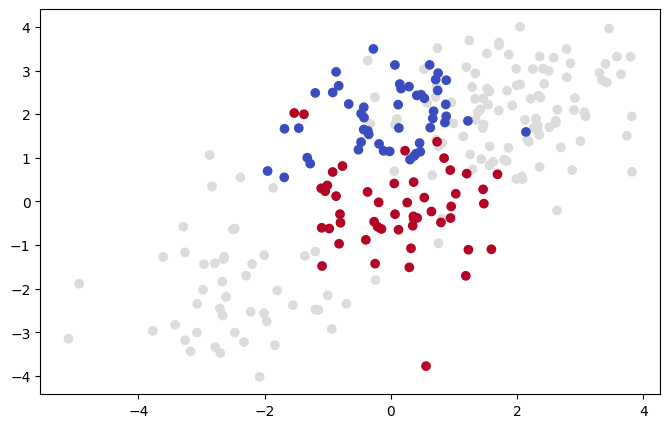

In [148]:
# 1. Setup the initial 2-class data (Resetting so X and y don't grow infinitely)
rng = np.random.default_rng(0)
X_base = rng.standard_normal((200, 2))
X_base[:100] += 2
X_base[100:150] -= 2
y_base = np.array([1]*150 + [2]*50)

# 2. Add the 3rd class
rng_new = np.random.default_rng(42)
X_new = rng_new.standard_normal((50, 2))
y_new = np.array([0]*50)
X_new[:, 1] += 2  # Shift the new points up on the Y-axis

# Combine base data with new class
X = np.vstack([X_base, X_new])
y = np.hstack([y_base, y_new])
fig , ax = plt.subplots(figsize=(8,5))
ax.scatter(X[:,0], X[:,1], c=y, cmap= 'coolwarm')

In [150]:
# 1. Split the data to ensure we have an "unseen" test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# 2. Define the parameter grid
# We use logarithmic scales (0.1, 1, 10...) because SVM sensitivity 
# often changes exponentially.
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [0.01, 0.1, 1, 5, 10],
    'decision_function_shape': ['ovo'] # Keeping our multiclass strategy
}

# 3. Setup the Grid Search
grid_search = GridSearchCV(
    SVC(kernel='rbf'), 
    param_grid, 
    cv=5,                # 5-fold cross-validation
    scoring='accuracy', 
    verbose=1            # Shows progress
)

# 4. Run the search
grid_search.fit(X_train, y_train)

# 5. Results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.2f}")

# 6. Evaluate on the final held-out test set
final_model = grid_search.best_estimator_
test_acc = final_model.score(X_test, y_test)
print(f"Final Test Accuracy: {test_acc:.2f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters: {'C': 1, 'decision_function_shape': 'ovo', 'gamma': 0.1}
Best CV Accuracy: 0.82
Final Test Accuracy: 0.87


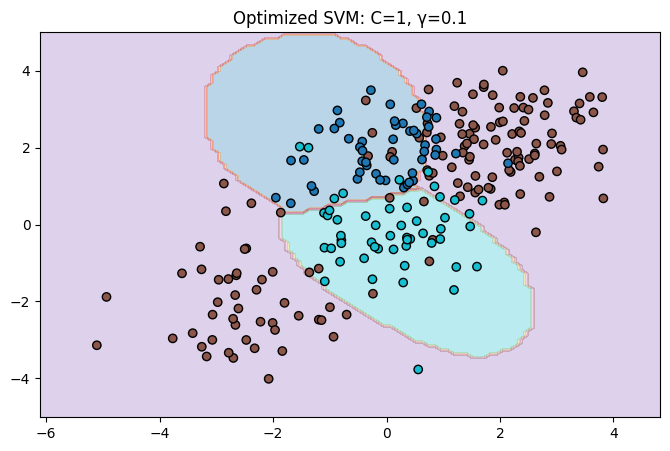

In [159]:
fig, ax = plt.subplots(figsize=(8, 5))
DecisionBoundaryDisplay.from_estimator(
    final_model, X, response_method="predict", cmap='tab10', alpha=0.3, ax=ax
)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', edgecolors='k')
ax.set_title(f"Optimized SVM: C={grid_search.best_params_['C']}, γ={grid_search.best_params_['gamma']}")
plt.show()

## Multiclass SVM Strategies: OvO vs. OvR

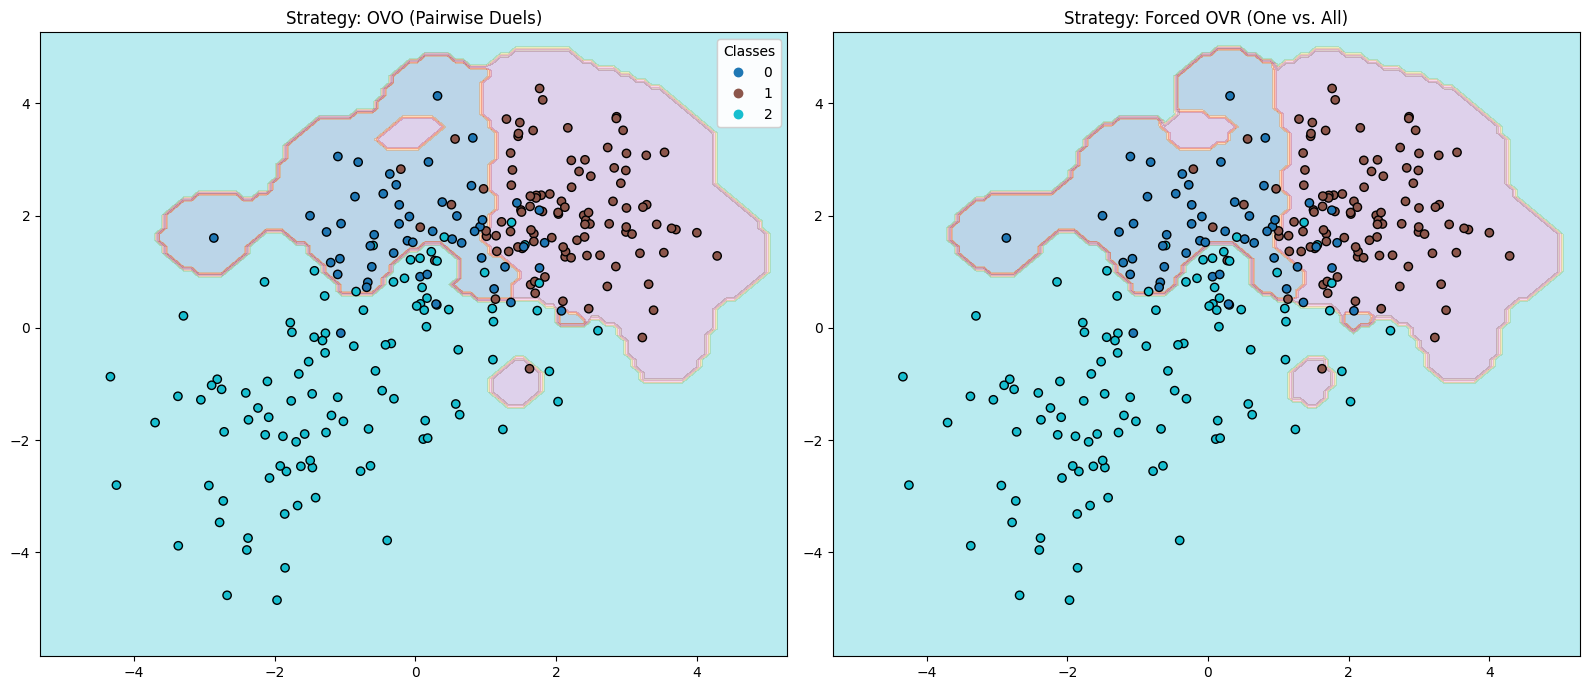

In [160]:
from sklearn.multiclass import OneVsRestClassifier

# 1. SETUP DATA (Standard 3-class setup)
rng = np.random.default_rng(123)
# Class 1 & 2
X = rng.standard_normal((200, 2))
X[:100] += 2
X[100:150] -= 2
y = np.array([1]*100 + [2]*100) # Balanced for simplicity

# Adding Class 0
X_new = rng.standard_normal((50, 2))
X_new[:, 1] += 2 
X = np.vstack([X, X_new])
y = np.hstack([y, [0]*50])

# 2. DEFINE MODELS
# Strategy A: Standard OvO (Built into SVC)
# High gamma makes boundaries "wiggly" so differences are easier to spot
model_ovo = SVC(kernel="rbf", C=10, gamma=2, decision_function_shape='ovo')

# Strategy B: Forced OvR (Truly training 3 separate models)
model_ovr_forced = OneVsRestClassifier(SVC(kernel="rbf", C=10, gamma=2))

# 3. FIT MODELS
model_ovo.fit(X, y)
model_ovr_forced.fit(X, y)

# 4. VISUAL COMPARISON
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
models = [model_ovo, model_ovr_forced]
titles = ["Strategy: OVO (Pairwise Duels)", "Strategy: Forced OVR (One vs. All)"]

for i, model in enumerate(models):
    # Plot decision regions
    DecisionBoundaryDisplay.from_estimator(
        model, 
        X, 
        ax=axes[i], 
        response_method="predict", 
        cmap='tab10', 
        alpha=0.3
    )
    
    # Plot data points
    scatter = axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', edgecolors='k')
    axes[i].set_title(titles[i])
    
    # Add legend to the first plot
    if i == 0:
        legend = axes[i].legend(*scatter.legend_elements(), title="Classes")
        axes[i].add_artist(legend)

plt.tight_layout()
plt.show()

*Since Support Vector Machines (SVMs) are natively binary classifiers, they use two primary strategies to handle datasets with more than two classes.*

---

### 1. One-vs-One (OvO)
**The "Round-Robin Tournament" Approach**

* **How it works:** The algorithm trains a separate classifier for **every possible pair** of classes.
* **Math:** For $K$ classes, it creates $\frac{K(K-1)}{2}$ models.
    * *Example (3 Classes):* 0 vs 1, 1 vs 2, 0 vs 2.
* **Decision Rule:** Each model "votes" for a winner. The class with the most votes across all models wins.
* **Best for:** SVMs specifically. Because SVMs scale poorly with data size ($O(n^3)$), training many small models on subsets of data is often faster than one large model.
* **Pros:** Robust against imbalanced data; boundaries between two classes are not distorted by other classes.

---

### 2. One-vs-Rest (OvR / One-vs-All)
**The "Me vs. The World" Approach**

* **How it works:** The algorithm trains **one classifier per class**, comparing that class against all other classes combined.
* **Math:** For $K$ classes, it creates exactly $K$ models.
    * *Example (3 Classes):* 0 vs [1 & 2], 1 vs [0 & 2], 2 vs [0 & 1].
* **Decision Rule:** It calculates a "confidence score" (distance from the boundary) for each class. The class with the highest score wins.
* **Best for:** Most other algorithms (Logistic Regression, etc.) where training on the full dataset is efficient.
* **Pros:** Fewer models to store and faster prediction time for a high number of classes.

---

### Comparison Table

| Feature | One-vs-One (OvO) | One-vs-Rest (OvR) |
| :--- | :--- | :--- |
| **Number of Models** | High ($\approx K^2/2$) | Low ($K$) |
| **Training Speed** | Fast for SVM (small subsets) | Slow for SVM (full dataset) |
| **Prediction Speed** | Slower (checks more models) | Faster (checks fewer models) |
| **Boundary Focus** | Local (only cares about the pair) | Global (cares about the whole distribution) |
| **Scikit-Learn Default** | `SVC` (via LibSVM) | `LinearSVC` / `OneVsRestClassifier` |

> **Note:** In Scikit-Learn's `SVC`, even if you set `decision_function_shape='ovr'`, it still trains **OvO** models internally. It simply reformats the output scores to look like OvR. To get a true OvR training process, use the `OneVsRestClassifier` wrapper.